# 05 (Idea 1 adapted): Loss curves + per-sequence Pearson/Spearman by count-coverage quartile

Adapted from Claudia's `05_comparison_plots.ipynb` (Idea 2) to Idea 1's file
layout. Reproduces the same final combined figure: validation loss curves,
Pearson box plots, and Spearman box plots, split by test-set count-coverage
quartile, for the 5 final filtered Idea-1 runs.

Two things differ from the Idea-2 version, both handled below:
- Per-sequence correlations are CSV (`pearson_r_per_sequence.csv`,
  `spearman_r_per_sequence.csv`), not `.npy` files.
- The `spearman_r_per_sequence.csv` file did not exist before this notebook
  was written -- `scripts/evaluate_new_models.py` was extended to save it,
  and the 5 runs below need to be re-evaluated once (fast, no retraining,
  just a forward pass) before this notebook will find real Spearman data.

## Set-up

In [1]:
import pylbsr.notebooks
import pylbsr.misc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
import gzip
import io
from pathlib import Path

import torch
from parnet_demo_utils.sparse_utils import torch_sparse_to_dense
import sys


In [2]:
_notebook_name = "05_comparison_plots_idea1.ipynb"
_notebook_path = f"notebooks/globalclip/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)
logger = pylbsr.misc.init_logger(_notebook_name)
PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

sys.path.insert(0, str(PROJECT_DIR / "src"))
from globalclip_utils import GlobalCLIPDataset

# Idea 1's own repo root -- training runs and their evaluation outputs both
# live under here, unlike Idea 2's separate RUNS_DIR.
RUNS_DIR = PROJECT_DIR / "results" / "globalclip"
EVAL_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.server.yaml").read_text())
DATASET_PATH = Path(_fp_cfg["data"]["globalclip_lysate_noNHS"]["pt"])
if not DATASET_PATH.is_absolute():
    DATASET_PATH = PROJECT_DIR / DATASET_PATH


[21:30:08] INFO - Project directory: /mnt/storage1/workspace/pgoldemund/parnet--idea1-reconstruction-head


## Define the 5 runs to compare

In [3]:
# Each entry: (training run-id, model_type subfolder, evaluate_new_models.py
# output folder). model_type is needed because Idea 1's directory layout is
# results/globalclip/<model_type>/<run_id>/, not flat like Idea 2's.
RUNS = {
    "Standard, global":            dict(run_id="globalclip.standard.filtered_v1",              model_type="standard", eval_dir="new_filtered_standard_global"),
    "Standard, positional":        dict(run_id="globalclip.standard.positional_filtered_v1",    model_type="standard", eval_dir="new_filtered_standard_positional"),
    "CNN-only, global":            dict(run_id="ablation_cnn_only_filtered_v1",                 model_type="cnn_only", eval_dir="new_filtered_cnn_global"),
    "CNN-only, positional":        dict(run_id="ablation_cnn_only_positional_filtered_v1",      model_type="cnn_only", eval_dir="new_filtered_cnn_positional"),
    "CNN-only, positional (21M)":  dict(run_id="ablation_cnn_only_positional_21m_filtered_v1",  model_type="cnn_only", eval_dir="new_filtered_cnn_positional_21m"),
}

MODEL_COLORS = {
    "Standard, global":           "tab:gray",
    "Standard, positional":       "tab:blue",
    "CNN-only, global":           "tab:green",
    "CNN-only, positional":       "tab:orange",
    "CNN-only, positional (21M)": "tab:red",
}


⏱ 0.00 s (00:00:00)


## Helper functions

In [4]:
def load_loss_curve(cfg):
    """Load epoch-level validation/train loss curves from a run's metrics.csv.
    Picks the latest version_N/ (Lightning starts a new one each time
    training is resumed in the same output dir)."""
    run_dir = RUNS_DIR / cfg["model_type"] / cfg["run_id"]
    csv_path = sorted((run_dir / "csv_logs").glob("version_*/metrics.csv"))[-1]
    df = pd.read_csv(csv_path)
    val   = df[["epoch", "val/loss"]].dropna(subset=["val/loss"])
    train = df[["epoch", "train/loss_epoch"]].dropna(subset=["train/loss_epoch"])
    return val.merge(train, on="epoch")


def load_test_correlations(cfg):
    """Load per-sequence Pearson/Spearman, in the same row order as the
    filtered test set (see load_test_counts below) so they can be zipped
    together by index.

    Returns (pearson, spearman) arrays, or None if either file is missing --
    spearman_r_per_sequence.csv will be missing until evaluate_new_models.py
    (with the CSV-export patch) has been re-run for this run_id.
    """
    eval_dir = EVAL_DIR / cfg["eval_dir"] / cfg["model_type"]
    pearson_path = eval_dir / "pearson_r_per_sequence.csv"
    spearman_path = eval_dir / "spearman_r_per_sequence.csv"

    if not pearson_path.exists():
        logger.warning(f"{cfg['eval_dir']}: missing {pearson_path.name}")
        return None
    if not spearman_path.exists():
        logger.warning(
            f"{cfg['eval_dir']}: missing {spearman_path.name} -- re-run "
            "evaluate_new_models.py for this run_id after pulling the "
            "spearman-per-sequence patch."
        )
        return None

    pearson = pd.read_csv(pearson_path)["pearson_r"].to_numpy()
    spearman = pd.read_csv(spearman_path)["spearman_r"].to_numpy()
    return pearson, spearman


def load_test_counts():
    """Total signal (count coverage) per filtered test-set sequence, in the
    same order pearson_r_per_sequence.csv's sequence_index refers to.

    Reuses GlobalCLIPDataset with max_total_signal=1000 (the same filter
    evaluate_new_models.py applies), so the resulting per-sequence order and
    count exactly matches what each run was actually evaluated on -- unlike
    Idea 2, Idea 1 does not have separate raw/filtered dataset files, the
    filter is applied at load time.
    """
    ds = GlobalCLIPDataset(DATASET_PATH, split="test", seq_len=600,
                            total_key="globalCLIP", max_total_signal=1000)
    # GlobalCLIPDataset already returns "signal" as a dense tensor
    # (converted internally in __getitem__), so no torch_sparse_to_dense
    # call is needed here, unlike when loading the raw .pt.gz directly.
    return np.array([
        ds[i]["signal"].sum().item() for i in range(len(ds))
    ])


N_QUANTILES = 4
QUARTILE_LABELS = ["Q1 (low)", "Q2", "Q3", "Q4 (high)"]
FONT_SIZES = {"title": 16, "axis_label": 14, "tick_label": 11, "legend": 11, "suptitle": 17}

_test_counts = load_test_counts()
logger.info(f"Filtered test set: {len(_test_counts)} sequences")


def build_quartile_df(cfg):
    """Bin filtered test-set sequences into count-coverage quartiles and
    attach each sequence's per-sequence Pearson/Spearman. Returns None if
    per-sequence correlations are not available yet for this run."""
    corr = load_test_correlations(cfg)
    if corr is None:
        return None
    pearson, spearman = corr

    n = min(len(_test_counts), len(pearson), len(spearman))
    if len({len(_test_counts), len(pearson), len(spearman)}) > 1:
        logger.warning(f"{cfg['eval_dir']}: length mismatch, truncating to {n}")
    counts, pearson, spearman = _test_counts[:n], pearson[:n], spearman[:n]

    quartile_idx = pd.qcut(counts, N_QUANTILES, labels=False, duplicates="drop")
    return pd.DataFrame({"count": counts, "quartile": quartile_idx,
                          "pearson": pearson, "spearman": spearman})


Loading (gz) globalclip_lysate_noNHS_600bp_signalfiltered.pt.gz split='test'... 

loaded 4946 samples.
Filtered 50 of 4946 'test' windows with total signal > 1000 (4896 remaining).


[21:30:30] INFO - Filtered test set: 4896 sequences


⏱ 21.98 s (00:00:21)


## Final combined figure: loss curves + Pearson/Spearman quartile box plots

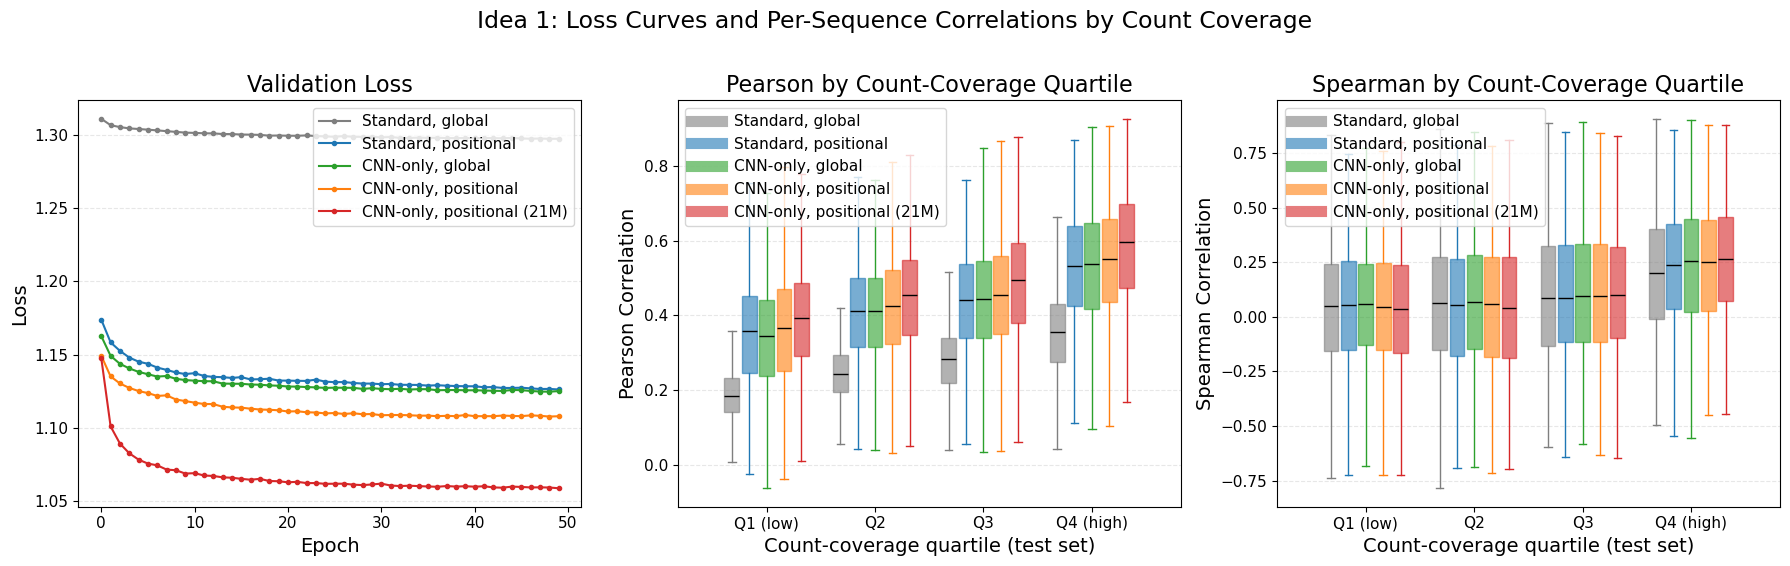

⏱ 1.55 s (00:00:01)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Panel 1: validation loss curves, all 5 runs together ---
for label, cfg in RUNS.items():
    try:
        df = load_loss_curve(cfg)
        axes[0].plot(df["epoch"], df["val/loss"], marker="o", markersize=3,
                     color=MODEL_COLORS.get(label, "gray"), label=label)
    except (FileNotFoundError, IndexError):
        logger.warning(f"Missing loss data: {label}")

axes[0].set_title("Validation Loss", fontsize=FONT_SIZES["title"])
axes[0].set_xlabel("Epoch", fontsize=FONT_SIZES["axis_label"])
axes[0].set_ylabel("Loss", fontsize=FONT_SIZES["axis_label"])
axes[0].tick_params(labelsize=FONT_SIZES["tick_label"])
axes[0].legend(fontsize=FONT_SIZES["legend"], frameon=True, loc="upper right")
axes[0].grid(axis="y", alpha=0.3, linestyle="--")

# --- Build per-sequence quartile DataFrames once, reused for panels 2 and 3 ---
all_dfs = {label: build_quartile_df(cfg) for label, cfg in RUNS.items()}
all_dfs = {label: df for label, df in all_dfs.items() if df is not None}


def _quartile_boxplot(ax, metric, title, ylabel):
    if not all_dfs:
        ax.set_title(f"{title} (no data)", fontsize=FONT_SIZES["title"])
        return
    n_runs = len(all_dfs)
    width = 0.8 / n_runs
    x_base = np.arange(N_QUANTILES)
    for i, (label, df) in enumerate(all_dfs.items()):
        data_per_q = [df.loc[df["quartile"] == q, metric].values for q in range(N_QUANTILES)]
        pos = x_base + (i - (n_runs - 1) / 2) * width
        color = MODEL_COLORS.get(label, "gray")
        bp = ax.boxplot(data_per_q, positions=pos, widths=width * 0.85,
                         patch_artist=True, showfliers=False)
        for box in bp["boxes"]:
            box.set_facecolor(color); box.set_alpha(0.6); box.set_edgecolor(color)
        for key in ("whiskers", "caps"):
            for line in bp[key]:
                line.set_color(color)
        for median in bp["medians"]:
            median.set_color("black")
        ax.plot([], [], color=color, linewidth=8, alpha=0.6, label=label)
    ax.set_xticks(x_base)
    ax.set_xticklabels(QUARTILE_LABELS, fontsize=FONT_SIZES["tick_label"])
    ax.set_xlabel("Count-coverage quartile (test set)", fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel(ylabel, fontsize=FONT_SIZES["axis_label"])
    ax.set_title(title, fontsize=FONT_SIZES["title"])
    ax.tick_params(labelsize=FONT_SIZES["tick_label"])
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.legend(fontsize=FONT_SIZES["legend"], frameon=True, loc="best")


# --- Panel 2: Pearson by quartile ---
_quartile_boxplot(axes[1], "pearson", "Pearson by Count-Coverage Quartile", "Pearson Correlation")

# --- Panel 3: Spearman by quartile ---
_quartile_boxplot(axes[2], "spearman", "Spearman by Count-Coverage Quartile", "Spearman Correlation")

plt.suptitle("Idea 1: Loss Curves and Per-Sequence Correlations by Count Coverage",
             fontsize=FONT_SIZES["suptitle"], y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "idea1_final_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
